In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
import seaborn as sns

In [ ]:
#import the dataset, see the info about the dataset and check for missing values
df=pd.read_csv(r'C:\Users\tatra\Titanic-Dataset.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
#missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
# Separate numeric and object columns for further analysis
df_num=df.select_dtypes(include=[np.number])
df_obj=df.select_dtypes(include=[object])
df_num.info()
df_obj.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Age          714 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Fare         891 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 48.9 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Name      891 non-null    object
 1   Sex       891 non-null    object
 2   Ticket    891 non-null    object
 3   Cabin     204 non-null    object
 4   Embarked  889 non-null    object
dtypes: object(5)
memory usage: 34.9+ KB


In [ ]:
# From the info we can see that the Age column has 177 missing values, and the Cabin column has 687 missing values.
# The Cabin column has a lot of missing values, so we will drop this column.
# The Age column has a lot of missing values, but we will fill these missing values with the median value of the Age
# column.
df_num['Age'].fillna(df_num['Age'].median(), inplace=True)
df_obj.drop('Cabin', axis=1, inplace=True)
df_num.info()
df_obj.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Age          891 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Fare         891 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 48.9 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Name      891 non-null    object
 1   Sex       891 non-null    object
 2   Ticket    891 non-null    object
 3   Embarked  889 non-null    object
dtypes: object(4)
memory usage: 28.0+ KB


In [15]:
# Embarked column has 2 missing values, we will fill these missing values with the mode value of the Embarked column.
df_obj['Embarked'].fillna(df_obj['Embarked'].mode()[0], inplace=True)
df_obj.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Name      891 non-null    object
 1   Sex       891 non-null    object
 2   Ticket    891 non-null    object
 3   Embarked  891 non-null    object
dtypes: object(4)
memory usage: 28.0+ KB


In [ ]:
# Encode the categorical variables, drop Name and Ticket columns because they are not useful for our analysis
df_obj.drop(['Name', 'Ticket'], axis=1, inplace=True)
df_obj_encoded=pd.get_dummies(df_obj, drop_first=True)
df_obj_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Sex_male    891 non-null    bool 
 1   Embarked_Q  891 non-null    bool 
 2   Embarked_S  891 non-null    bool 
dtypes: bool(3)
memory usage: 2.7 KB


In [35]:
df_obj_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Sex_male    891 non-null    bool 
 1   Embarked_Q  891 non-null    bool 
 2   Embarked_S  891 non-null    bool 
dtypes: bool(3)
memory usage: 2.7 KB


In [ ]:
# Concatenate the numeric and encoded object dataframes, drop passengerId column because it is not useful for our analysis
df_final=pd.concat([df_num, df_obj_encoded], axis=1)
df_final.drop(['PassengerId'], axis=1, inplace=True)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Sex_male    891 non-null    bool   
 7   Embarked_Q  891 non-null    bool   
 8   Embarked_S  891 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 44.5 KB


C:\Users\tatra\AppData\Local\Temp\ipykernel_2956\1713046720.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=survived_corr.values, y=survived_corr.index, palette='coolwarm')


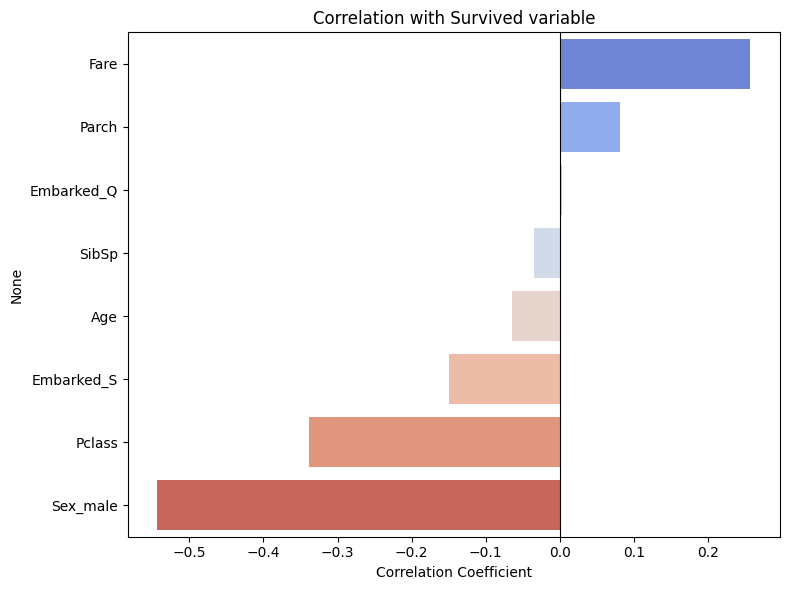

In [44]:
corr_matrix = df_final.corr()
survived_corr = corr_matrix['Survived'].drop('Survived').sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=survived_corr.values, y=survived_corr.index, palette='coolwarm')
plt.title('Correlation with Survived variable')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [55]:
# Considering the absolute value of the correlation coefficients, the 'Sex_male', 'Pclass' and 'Fare' variables
# were found to have the strongest correlation with the 'Survived' variable. We will use these variables for our linear regression model.

In [ ]:
# Define the features and target variable for the linear regression model, and convert the features to float type
X= df_final[['Sex_male', 'Pclass', 'Fare']]
y= df_final['Survived']
X = df_final[['Sex_male', 'Pclass', 'Fare']].astype(float)

Accuracy: 0.7821229050279329
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       105
           1       0.75      0.70      0.73        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



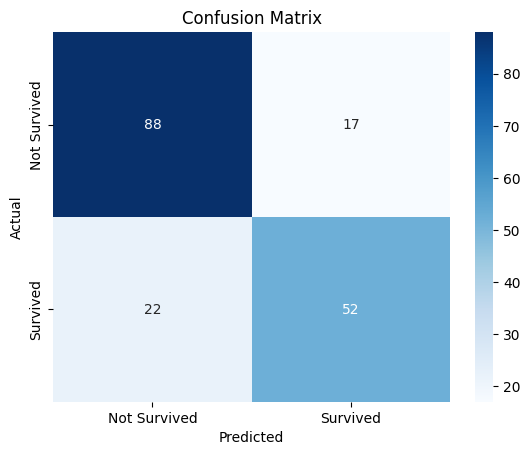

In [72]:
# Split the data into training and testing sets, and train a logistic regression model to predict the survival of
# passengers based on the selected features.
# Logistic regression is used instead of linear regression because the target variable is binary
# (Survived or Not Survived).

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", model.score(X_test, y_test))

# Classification report
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# The accuracy of the model is around 80%, which indicates that the model is performing reasonably well in predicting
# the survival of passengers based on the selected features. The model is better at predicting passengers who
# did not survive (precision and recall for 'Not Survived' class are higher) compared to those who survived.
# This could be due to the imbalance in the dataset, as there are more passengers who did not survive than those who did.
# This is a class imbalance, which should be taken into account when evaluating the model's performance.

In [74]:
# Let's take back the 'Age' variable and see how it affects the model's performance.
# We will include the 'Age' variable in our features and retrain the logistic regression model.
X2 = df_final[['Sex_male', 'Pclass', 'Fare', 'Age']].astype(float)
y2 = df_final['Survived']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

scaler2 = StandardScaler()
X2_train = scaler2.fit_transform(X2_train)
X2_test = scaler2.transform(X2_test)

model2 = LogisticRegression()
model2.fit(X2_train, y2_train)
y2_pred = model2.predict(X2_test)

print("Accuracy:", model2.score(X2_test, y2_test))
print(classification_report(y2_test, y2_pred))

Accuracy: 0.7932960893854749
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       105
           1       0.77      0.72      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [ ]:
# Let's compare the performance of the two models using the F1-score for each class.
report1 = classification_report(y_test, y_pred, output_dict=True)
report2 = classification_report(y2_test, y2_pred, output_dict=True)

comparison = pd.DataFrame({
    '1st Model (3 variables)': pd.DataFrame(report1).T['f1-score'],
    '2nd Model  (Age included)': pd.DataFrame(report2).T['f1-score']
})

print(comparison)

              1st Model (3 variables)  2nd Model  (Age included)
0                            0.818605                   0.827907
1                            0.727273                   0.741259
accuracy                     0.782123                   0.793296
macro avg                    0.772939                   0.784583
weighted avg                 0.780847                   0.792086


In [ ]:
# The model has a slightly higher accuracy when the 'Age' variable is included, but the F1-scores for both
# classes are very similar between the two models. This suggests that including the 'Age' variable does not
# significantly improve the model's performance in predicting survival.


In [78]:
# Let's try balancing the regression
model3 = LogisticRegression(class_weight='balanced')
model3.fit(X2_train, y2_train)
y3_pred = model3.predict(X2_test)
print("Accuracy:", model3.score(X2_test, y2_test))
print(classification_report(y2_test, y3_pred))


Accuracy: 0.8100558659217877
              precision    recall  f1-score   support

           0       0.87      0.79      0.83       105
           1       0.74      0.84      0.78        74

    accuracy                           0.81       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.81      0.81       179



In [79]:
# Let's take a look at the 3 models' performance side by side using the F1-score for each class.
report3 = classification_report(y2_test, y3_pred, output_dict=True)
comparison = pd.DataFrame({
    '1st Model (3 variables)': pd.DataFrame(report1).T['f1-score'],
    '2nd Model  (Age included)': pd.DataFrame(report2).T['f1-score'],
    '3rd Model (Balanced)': pd.DataFrame(report3).T['f1-score']
})
print(comparison)

              1st Model (3 variables)  2nd Model  (Age included)  \
0                            0.818605                   0.827907   
1                            0.727273                   0.741259   
accuracy                     0.782123                   0.793296   
macro avg                    0.772939                   0.784583   
weighted avg                 0.780847                   0.792086   

              3rd Model (Balanced)  
0                         0.830000  
1                         0.784810  
accuracy                  0.810056  
macro avg                 0.807405  
weighted avg              0.811318  


In [ ]:
# Random Forest Classifier could be a good choice for this dataset, as it can handle both numerical and categorical
# variables, and it is less affected by class imbalance compared to logistic regression.
# Additionally, Random Forest can capture complex interactions between features, which may improve the model's
# performance in predicting survival.

In [80]:
from sklearn.ensemble import RandomForestClassifier

model4 = RandomForestClassifier(n_estimators=100, random_state=42)
model4.fit(X2_train, y2_train)
y4_pred = model4.predict(X2_test)
print("Accuracy:", model4.score(X2_test, y4_pred))
print(classification_report(y2_test, y4_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [81]:
report3 = classification_report(y2_test, y3_pred, output_dict=True)
report4 = classification_report(y2_test, y4_pred, output_dict=True)

comparison2 = pd.concat([
    pd.DataFrame(report2).T[['precision', 'recall', 'f1-score']].round(3),
    pd.DataFrame(report3).T[['precision', 'recall', 'f1-score']].round(3),
    pd.DataFrame(report4).T[['precision', 'recall', 'f1-score']].round(3)
], axis=1, keys=['LogReg', 'Balanced', 'Random Forest'])

print(comparison2)

                LogReg                  Balanced                  \
             precision recall f1-score precision recall f1-score   
0                0.809  0.848    0.828     0.874  0.790    0.830   
1                0.768  0.716    0.741     0.738  0.838    0.785   
accuracy         0.793  0.793    0.793     0.810  0.810    0.810   
macro avg        0.789  0.782    0.785     0.806  0.814    0.807   
weighted avg     0.792  0.793    0.792     0.818  0.810    0.811   

             Random Forest                  
                 precision recall f1-score  
0                    0.817  0.848    0.832  
1                    0.771  0.730    0.750  
accuracy             0.799  0.799    0.799  
macro avg            0.794  0.789    0.791  
weighted avg         0.798  0.799    0.798  


In [ ]:
# All in all, the balanced Logistic model is the best performing model, but we should consider the Random
# Forest model, with the whole dataset, as it performs better with higher number of variables.
X_full = df_final.drop(columns=['Survived']).astype(float)
y_full = df_final['Survived']

X_full_train, X_full_test, y_full_train, y_full_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

# With random forest, we don't need to scale the features, but we will do it anyway to see if it improves the model's performance.
scaler_full = StandardScaler()
X_full_train = scaler_full.fit_transform(X_full_train)
X_full_test = scaler_full.transform(X_full_test)

model5 = RandomForestClassifier(n_estimators=100, random_state=42)
model5.fit(X_full_train, y_full_train)
y5_pred = model5.predict(X_full_test)

print("Accuracy:", model5.score(X_full_test, y_full_test))
print(classification_report(y_full_test, y5_pred))

Accuracy: 0.8212290502793296
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



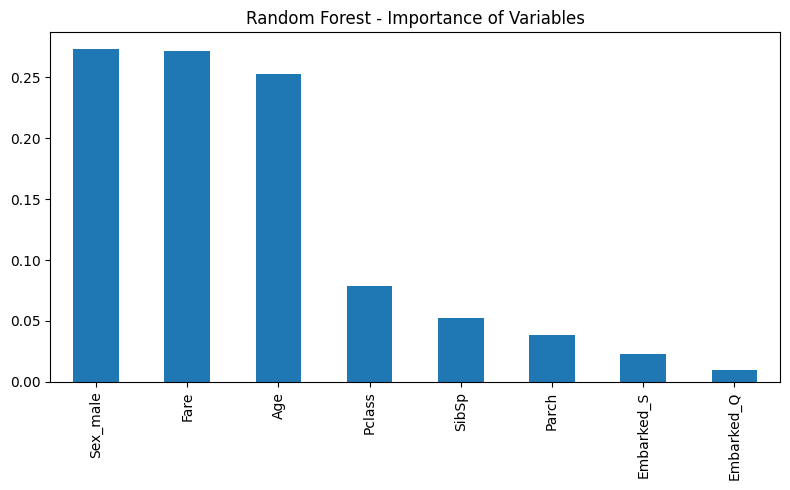

In [88]:
# Let's check which features are the most important in the Random Forest model.
importance_rf = pd.Series(model5.feature_importances_, index=X_full.columns)
importance_rf.sort_values(ascending=False).plot(kind='bar', figsize=(8,5))
plt.title('Random Forest - Importance of Variables')
plt.tight_layout()
plt.show()

In [89]:
# We can see that from the full dataset, the random forest model found the same variables important as the logistic regression model, but it also found the 'Age' variable important, which was not the case in the logistic regression model. This suggests that the Random Forest model is able to capture more complex relationships between the features and the target variable, which may explain its better performance compared to the logistic regression models.
# Let's try the top 3 important variables from the Random Forest model and see how it performs.
X_top3 = df_final[['Sex_male', 'Pclass', 'Fare']].astype(float)
y_top3 = df_final['Survived']
X_top3_train, X_top3_test, y_top3_train, y_top3_test = train_test_split(X_top3, y_top3, test_size=0.2, random_state=42)
scaler_top3 = StandardScaler()
X_top3_train = scaler_top3.fit_transform(X_top3_train)
X_top3_test = scaler_top3.transform(X_top3_test)
model_top3 = RandomForestClassifier(n_estimators=100, random_state=42)
model_top3.fit(X_top3_train, y_top3_train)
y_top3_pred = model_top3.predict(X_top3_test)
print("Accuracy:", model_top3.score(X_top3_test, y_top3_test))
print(classification_report(y_top3_test, y_top3_pred))


Accuracy: 0.8156424581005587
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.81      0.82      0.81       179



In [ ]:
# We can conclude, that the Random forest model with the top 3 important variables performs almost as well as 
# the model with all variables, which suggests that these top 3 variables are indeed the most influential in predicting 
# survival on the Titanic. This also indicates that we can achieve good performance with a simpler model that 
# focuses on the most important features, which can be beneficial for interpretability and computational efficiency.

# Let's see the strongest insights through the top 3 important variables:

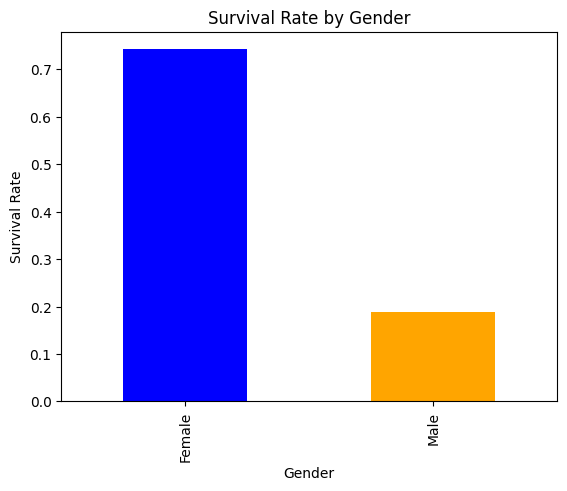

In [ ]:
# 1. Survival Rate by Gender
df_final.groupby('Sex_male')['Survived'].mean().plot(kind='bar', color=['blue', 'orange'])
plt.title('Survival Rate by Gender')
plt.xticks([0, 1], ['Female', 'Male'])
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.show()

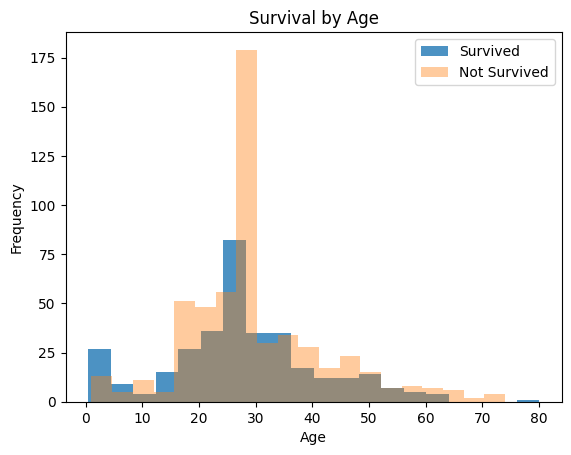

In [106]:
# 2. Survival by Age
df_final[df_final['Survived']==1]['Age'].plot(kind='hist', alpha=0.8, label='Survived', bins=20)
df_final[df_final['Survived']==0]['Age'].plot(kind='hist', alpha=0.4, label='Not Survived', bins=20)
plt.title('Survival by Age')
plt.xlabel('Age')
plt.legend()
plt.show()

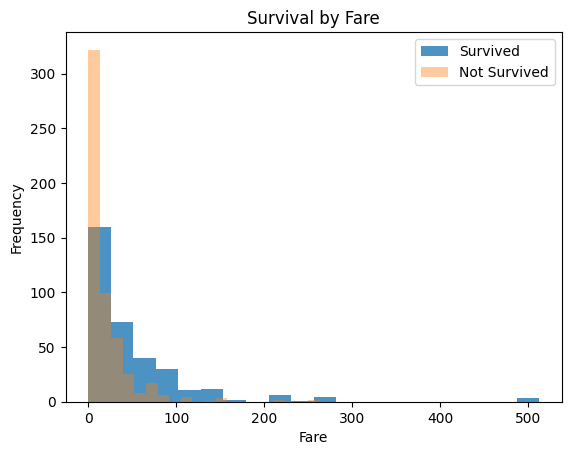

In [107]:
# 3. Survival by Fare
df_final[df_final['Survived']==1]['Fare'].plot(kind='hist', alpha=0.8, label='Survived', bins=20)
df_final[df_final['Survived']==0]['Fare'].plot(kind='hist', alpha=0.4, label='Not Survived', bins=20)
plt.title('Survival by Fare')
plt.xlabel('Fare')
plt.legend()
plt.show()

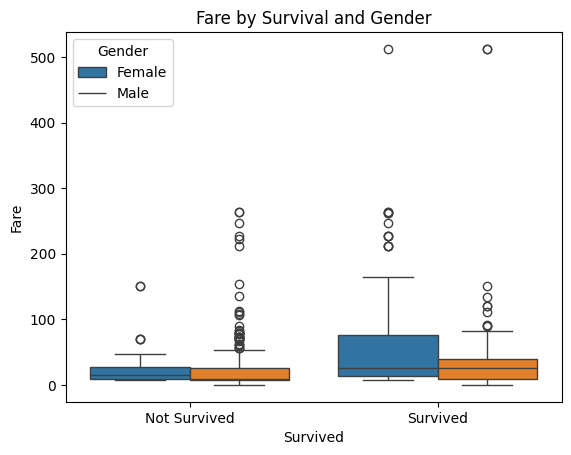

In [ ]:
# Combined insights boxplot:
sns.boxplot(data=df_final, x='Survived', y='Fare', hue='Sex_male')
plt.title('Fare by Survival and Gender')
plt.xticks([0,1], ['Not Survived', 'Survived'])
plt.legend(title='Gender', labels=['Female', 'Male'])
plt.show()

In [ ]:
# Based on the Titanic dataset, we can conclude, that:
1. Gender was a significant factor in survival. The female passengers had a much higher survival rate compared to male passengers.
2. Although age was not found to be a strong predictor, the socio-economic status/ the fare paid was an important factor in survival.
3. Passengers who paid higher fares had better chances of survival.